In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [6]:
df = pd.read_csv("soil_ph_dataset.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (1000, 8)


,Image,R,G,B,H,S,V,pH
0,soil_0001.jpg,208,122,105,9.93,126.74,207.76,5.87
1,soil_0002.jpg,237,172,125,25.19,120.20,237.27,8.75
2,soil_0003.jpg,238,145,108,16.92,138.56,237.53,7.66
3,soil_0004.jpg,229,156,102,25.51,141.59,229.45,6.99
4,soil_0005.jpg,195,120,81,20.70,148.81,194.69,4.78


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Image   1000 non-null   object 
 1   R       1000 non-null   int64  
 2   G       1000 non-null   int64  
 3   B       1000 non-null   int64  
 4   H       1000 non-null   float64
 5   S       1000 non-null   float64
 6   V       1000 non-null   float64
 7   pH      1000 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 62.6+ KB
None


In [8]:
print(df.isnull().sum())

Image    0
R        0
G        0
B        0
H        0
S        0
V        0
pH       0
dtype: int64


In [9]:
print(df.describe())

                R            G            B            H            S  \
count  1000.00000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    215.73100   142.210000   104.090000    20.381450   132.400720   
std      23.79182    22.122054    18.463337     5.933401    13.627384   
min     157.00000    83.000000    55.000000     1.200000    93.780000   
25%     196.00000   124.000000    90.000000    16.547500   122.837500   
50%     216.00000   141.000000   104.000000    20.240000   132.255000   
75%     235.00000   160.000000   118.000000    24.492500   141.332500   
max     255.00000   199.000000   158.000000    39.240000   180.360000   

                 V           pH  
count  1000.000000  1000.000000  
mean    215.712270     6.451220  
std      23.791821     1.460649  
min     156.860000     4.020000  
25%     196.437500     5.182500  
50%     216.340000     6.485000  
75%     235.455000     7.722500  
max     255.000000     9.000000  


#### EDA

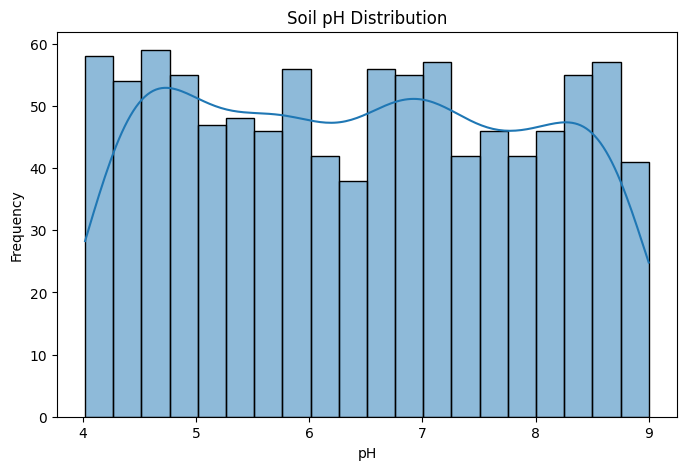

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["pH"], bins=20, kde=True)

plt.title("Soil pH Distribution")
plt.xlabel("pH")
plt.ylabel("Frequency")

plt.show()

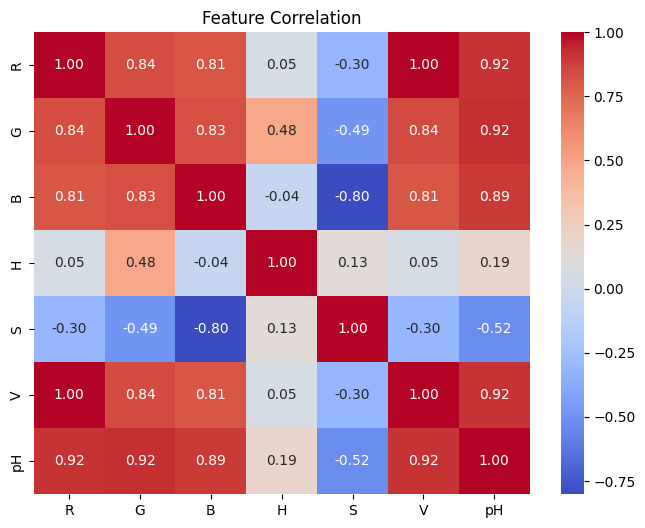

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["R", "G", "B", "H", "S", "V", "pH"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation")

plt.show()

In [12]:
X = df[["R", "G", "B", "H", "S", "V"]]

y = df["pH"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['R', 'G', 'B', 'H', 'S', 'V'], dtype='object')

Target:
pH


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 6)
Testing data: (200, 6)


In [14]:
models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(
            kernel="rbf",
            C=100,
            epsilon=0.05
        ))
    ]),

    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=42,
            early_stopping=True
        ))
    ])
}

In [15]:
results = {}

trained_models = {}

for name, model in models.items():

    print("Training:", name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

    trained_models[name] = model

    print("Completed\n")

Training: Linear Regression
Completed

Training: Random Forest
Completed

Training: XGBoost
Completed

Training: SVR
Completed

Training: Neural Network
Completed



In [16]:
results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by="RMSE"
)

results_df

,MAE,RMSE,R2 Score
Neural Network,0.256166,0.334844,0.946167
Linear Regression,0.268946,0.346500,0.942354
Random Forest,0.285221,0.362540,0.936893
XGBoost,0.297947,0.376374,0.931985
SVR,0.301341,0.404138,0.921581


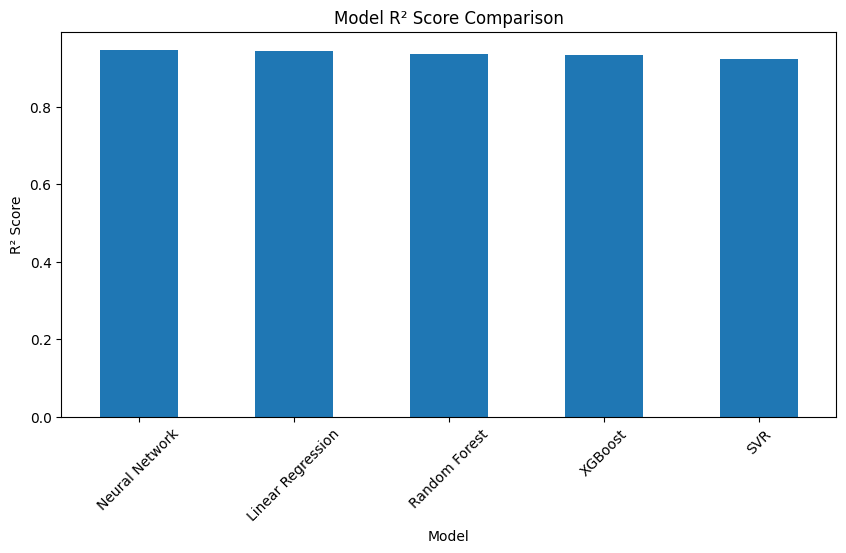

In [17]:
results_df["R2 Score"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=45)

plt.show()

In [18]:
best_model_name = results_df["RMSE"].idxmin()

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print("RMSE:", results_df.loc[best_model_name, "RMSE"])
print("MAE:", results_df.loc[best_model_name, "MAE"])
print("R²:", results_df.loc[best_model_name, "R2 Score"])

Best Model: Neural Network
RMSE: 0.33484380967588984
MAE: 0.2561664847481563
R²: 0.9461669778285967


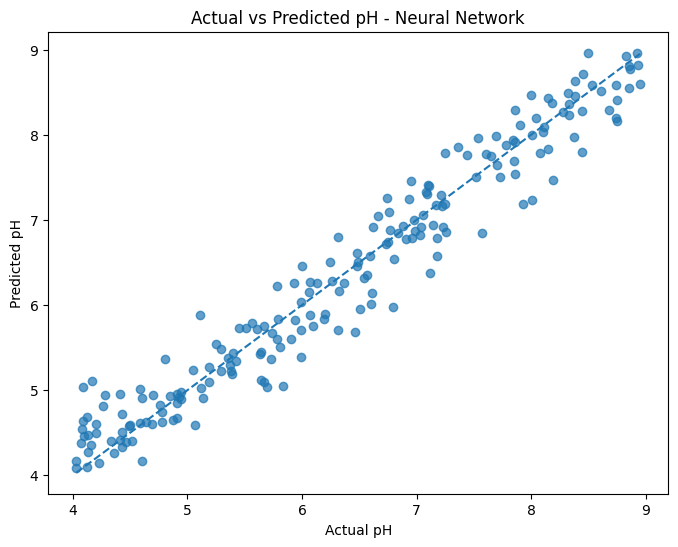

In [19]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.7
)

plt.xlabel("Actual pH")
plt.ylabel("Predicted pH")
plt.title(f"Actual vs Predicted pH - {best_model_name}")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [20]:
model_filename = "soil_ph_best_model.pkl"

joblib.dump(
    best_model,
    model_filename
)

print("Model saved successfully:")
print(model_filename)

Model saved successfully:
soil_ph_best_model.pkl


In [21]:
import joblib

model = joblib.load(
    "soil_ph_best_model.pkl"
)

print("Model loaded successfully")

Model loaded successfully


In [22]:
sample = [[
    180,   # R
    150,   # G
    110,   # B
    22,    # H
    99,    # S
    180    # V
]]

prediction = model.predict(sample)

print("Predicted Soil pH:", round(prediction[0], 2))

Predicted Soil pH: 6.63


d:\AI Soil detection\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)

Training R²: 0.9419199598268099
Testing R² : 0.9461669778285967
